In [284]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import RobustScaler, OneHotEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import scikit_posthocs as sp
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, accuracy_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Datan kuvailu ja preprosessointi
## 1.1 Yleiset perushavainnot

In [285]:
#Määritetään tyypit kaikille muuttujille

df = pd.read_csv('puut1.csv', 
                 index_col=0,
                 dtype={
                   "length": np.float64,
                   "diameter": np.float64,
                   "cones": np.int64,
                   "leaves": np.int64,
                   "bark_thickness": np.float64,
                   "seed_size": np.float64,
                   "fungi_present": np.bool,
                   "color_guess": np.object_,
                   "soil_pH": np.float64,
                   "collector_id": np.float64,
                   "collector_guess": np.float64,
                   }, 
                   na_values="*"
                   )

#Jaetaan data luokkiin

numeric_vars = ["length", "diameter", "cones", "leaves", "bark_thickness", "seed_size", "soil_pH"]
categoric_vars = ["fungi_present", "color_guess", "collector_guess"]
researcher_vars = ["collector_id"]

In [286]:
#Datan yleiset perushavainnot

print(f"Rivien määrä: {df.shape[0]}")
print(f"Numeeristen muuttujien määrä: {len(numeric_vars)}")
print(f"Kategoristen muuttujien määrä: {len(categoric_vars)}")

#Datan eheyden tarkistaminen

print(f"\nPuuttuvien arvojen määrä: {df.isnull().sum().sum()}")
print(f"Duplikaatti-arvojen määrä: {df.duplicated().sum()}")

Rivien määrä: 300
Numeeristen muuttujien määrä: 7
Kategoristen muuttujien määrä: 3

Puuttuvien arvojen määrä: 0
Duplikaatti-arvojen määrä: 20


## 1.2 Numeeristen muuttujien attribuutit

       length  diameter   cones    leaves  bark_thickness  seed_size  soil_pH
count  300.00    300.00  300.00    300.00          300.00     300.00   300.00
mean   267.45    115.53   87.84  10689.06            1.16       1.00     7.99
std     78.86     24.84   58.51   5691.38            0.27       0.02     1.04
min     69.08     73.96  -10.00   1067.00            0.62       0.83     4.85
25%    207.40     98.31   35.75   5720.00            0.98       1.00     7.32
50%    289.56    105.57   85.50  10631.00            1.09       1.00     8.02
75%    306.41    130.83  131.25  15620.50            1.31       1.00     8.63
max    516.90    214.82  199.00  19956.00            2.25       1.16    11.85

length              289.565000
diameter            105.575000
cones                85.500000
leaves            10631.000000
bark_thickness        1.090000
seed_size             1.000088
soil_pH               8.020000
dtype: float64 

length          Outliers: 6
diameter        Outliers: 5
cones  

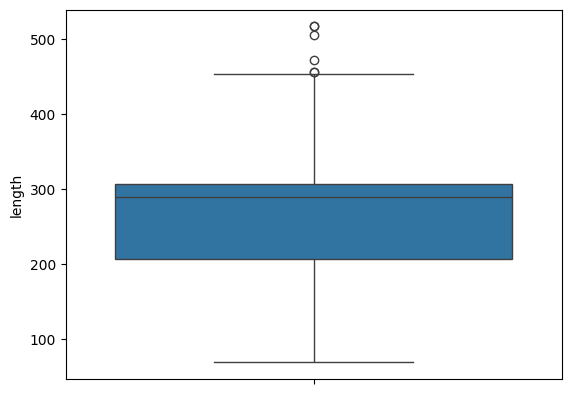

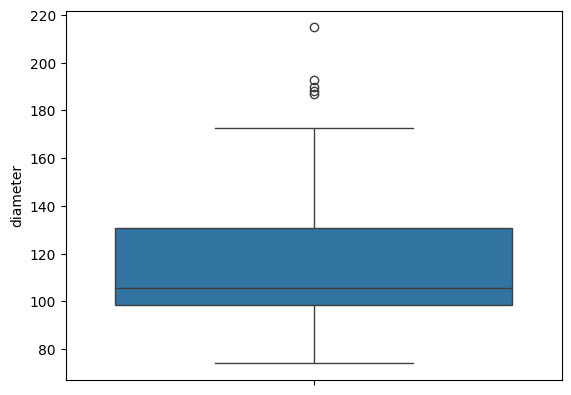

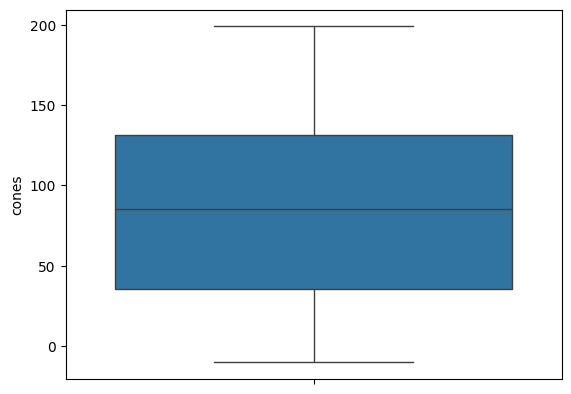

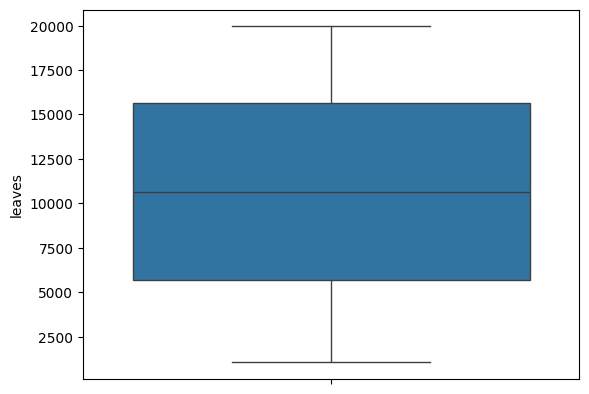

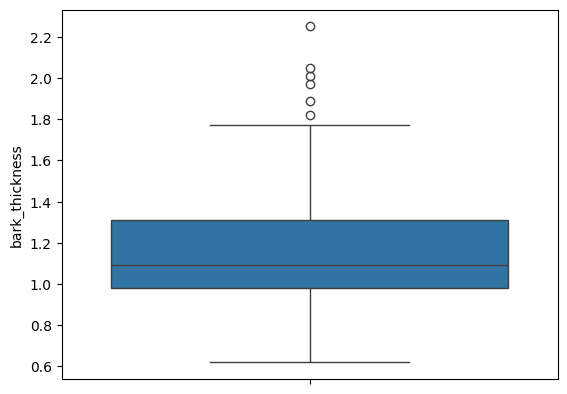

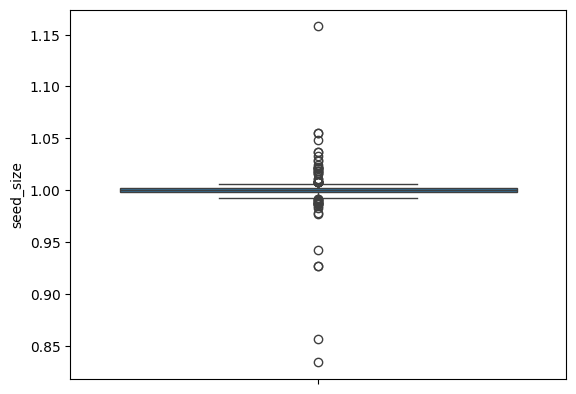

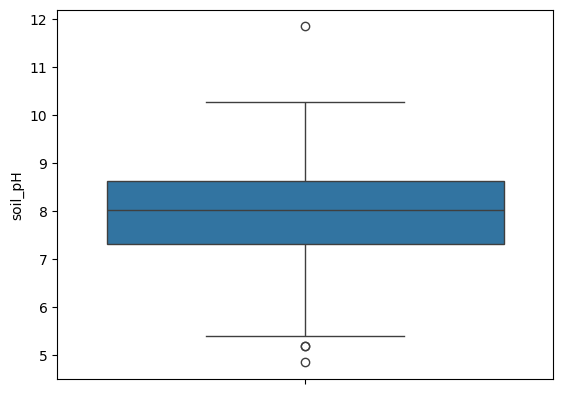

In [287]:
print(f"{df[numeric_vars].describe().round(2)}\n")
print(df[numeric_vars].median(), "\n")

for col in numeric_vars:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  print(f"{col:<15} Outliers: {len(outliers)}")


for col in numeric_vars:
  sns.boxplot(y = df[col], orient="v")
  plt.show()

## 1.3 Kategoristen muuttujien attribuutit

In [288]:
print(f"{df[categoric_vars].describe().round(2)}\n")
print(df[categoric_vars].value_counts())

       collector_guess
count           300.00
mean              1.98
std               0.77
min               1.00
25%               1.00
50%               2.00
75%               3.00
max               3.00

fungi_present  color_guess  collector_guess
False          mid-green    2.0                22
               lightish     3.0                19
True           lightish     2.0                18
               mid-green    1.0                16
False          dark         2.0                16
               mid-green    3.0                15
True           dark         2.0                13
               lightish     1.0                13
               darkish      1.0                12
               light        2.0                12
False          dark         3.0                12
True           light        1.0                11
False          light        3.0                11
               lightish     2.0                11
True           dark         1.0                1

In [289]:
"""
df['fungi_present_num'] = df['fungi_present'].replace([False, True], [0, 1])
df['color_guess_num'] = df['color_guess'].replace(
  ['dark', 'light', 'mid-green', 'lightish', 'darkish'],
  [0, 4, 2, 3, 1]
  )

numeric_categorical = ["fungi_present_num","color_guess_num"]
"""

'\ndf[\'fungi_present_num\'] = df[\'fungi_present\'].replace([False, True], [0, 1])\ndf[\'color_guess_num\'] = df[\'color_guess\'].replace(\n  [\'dark\', \'light\', \'mid-green\', \'lightish\', \'darkish\'],\n  [0, 4, 2, 3, 1]\n  )\n\nnumeric_categorical = ["fungi_present_num","color_guess_num"]\n'

## 1.4 Datan eheyden varmistaminen

In [290]:
df.cones = df.cones.abs()
df = df.drop_duplicates()

## 1.5 Muuttujien väliset suhteet

In [291]:
#Normaalijakauma
shapiro_test = stats.shapiro(df[numeric_vars], axis=0)
print(f'P-arvot numeeriselle datalle:')
for index, row in enumerate(shapiro_test.pvalue):
  print(f'{df[numeric_vars].columns[index]:<15} {row:<8.3} {"< 0.05" if row < 0.05  else "> 0.05"}')

P-arvot numeeriselle datalle:
length          1.42e-07 < 0.05
diameter        1.86e-14 < 0.05
cones           3.04e-08 < 0.05
leaves          1.04e-08 < 0.05
bark_thickness  5.77e-09 < 0.05
seed_size       2.18e-28 < 0.05
soil_pH         0.442    > 0.05


In [292]:
from scipy.stats import pearsonr, chi2_contingency, f_oneway
#Numeeristen muuttujien korrelaatio
for c1 in numeric_vars:
    for c2 in numeric_vars:
        if c1 < c2:
            corr, p = pearsonr(df[c1], df[c2])
            print(f"{c1:<15} vs {c2:<10}: r={corr:<5.2f}, p={p:.4f}")

length          vs seed_size : r=-0.05, p=0.3668
length          vs soil_pH   : r=-0.09, p=0.1504
diameter        vs length    : r=0.24 , p=0.0000
diameter        vs leaves    : r=-0.02, p=0.7052
diameter        vs seed_size : r=-0.02, p=0.6866
diameter        vs soil_pH   : r=-0.06, p=0.3508
cones           vs length    : r=0.04 , p=0.4667
cones           vs diameter  : r=0.06 , p=0.2976
cones           vs leaves    : r=0.04 , p=0.4864
cones           vs seed_size : r=0.08 , p=0.1772
cones           vs soil_pH   : r=0.06 , p=0.3309
leaves          vs length    : r=-0.03, p=0.6761
leaves          vs seed_size : r=-0.04, p=0.5576
leaves          vs soil_pH   : r=-0.01, p=0.8190
bark_thickness  vs length    : r=0.20 , p=0.0007
bark_thickness  vs diameter  : r=0.92 , p=0.0000
bark_thickness  vs cones     : r=0.05 , p=0.3771
bark_thickness  vs leaves    : r=-0.00, p=0.9473
bark_thickness  vs seed_size : r=-0.04, p=0.5106
bark_thickness  vs soil_pH   : r=-0.03, p=0.6224
seed_size       vs s

In [293]:
#Kategoristen muuttujien korrelaatio
for c1 in categoric_vars:
    for c2 in categoric_vars:
        if c1 < c2:
            ct = pd.crosstab(df[c1], df[c2])
            chi2, p, _, _ = chi2_contingency(ct)
            print(f"{c1:<15} vs {c2:<15}: chi2={chi2:<5.2f}, p={p:.4f}")

color_guess     vs fungi_present  : chi2=3.77 , p=0.4385
collector_guess vs fungi_present  : chi2=22.34, p=0.0000
collector_guess vs color_guess    : chi2=6.16 , p=0.6298


In [294]:
from scipy.stats import kruskal
import scikit_posthocs as sp
import pandas as pd

results = []

for num in numeric_vars:
    for cat in categoric_vars:

        temp = df[[num, cat]]
        groups = [g[num].values for _, g in temp.groupby(cat)]

        stat, p = kruskal(*groups)

        if p < 0.05:
         results.append({
            'numeric'    : num,
            'categorical': cat,
            'H_stat'     : round(stat, 4),
            'p_value'    : round(p, 4),
            'significant': 'Yes' if p < 0.05 else 'No'
        })   

# Summary Table
results_df = pd.DataFrame(results).sort_values('p_value')
print(results_df.to_string(index=False))

       numeric     categorical  H_stat  p_value significant
        length collector_guess 63.1837   0.0000         Yes
      diameter collector_guess 90.5637   0.0000         Yes
bark_thickness collector_guess 84.1340   0.0000         Yes
      diameter   fungi_present 14.0574   0.0002         Yes
bark_thickness   fungi_present 12.4700   0.0004         Yes


# 2 Datan klusterointi ja analyysi
## 2.1 Ominaisuuksien valinta

- Muuttujat diameter, length ja bark_thickness korreloivat vahvasti toistensa kanssa.
- Muuttujat collector_guess ja fungi_present korreloivat vahvasti toistensa kanssa.
- Muuttuja soil_pH on normaalisti jakautunut, joten sitä ei ole mielekästä jakaa luokkiin.